In [3]:
!pip install -q librosa

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
from glob import glob
import librosa
import librosa.display
import IPython.display as ipd
from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(color_pal)

In [5]:
from google.colab import files
files.upload()  # upload kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio
!unzip -q ravdess-emotional-speech-audio.zip -d /content/RAVDESS
!echo "✅ Dataset ready!"


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:21<00:00, 21.1MB/s]

✅ Dataset ready!


In [6]:
ravdess_path = "/content/RAVDESS"
audio_files = glob(f"{ravdess_path}/**/*.wav", recursive=True)
print(f"Total files found: {len(audio_files)}")  # Should be 1440
print("Sample path:", audio_files[0])

Total files found: 2880
Sample path: /content/RAVDESS/Actor_19/03-01-06-02-02-02-19.wav


In [7]:
emotion_map = {
    '01': 'neutral',  '02': 'calm',     '03': 'happy',
    '04': 'sad',      '05': 'angry',    '06': 'fearful',
    '07': 'disgust',  '08': 'surprised'
}

data = []
for filepath in audio_files:
    filename = filepath.split("/")[-1].replace(".wav", "")
    parts = filename.split("-")
    emotion_code = parts[2]
    actor_id     = int(parts[6])
    gender       = "female" if actor_id % 2 == 0 else "male"
    data.append({
        "path"   : filepath,
        "emotion": emotion_map[emotion_code],
        "actor"  : actor_id,
        "gender" : gender
    })

df = pd.DataFrame(data)
print(df.head())
print("\nEmotion distribution:")
print(df["emotion"].value_counts())

                                                path    emotion  actor gender
0  /content/RAVDESS/Actor_19/03-01-06-02-02-02-19...    fearful     19   male
1  /content/RAVDESS/Actor_19/03-01-08-02-01-02-19...  surprised     19   male
2  /content/RAVDESS/Actor_19/03-01-03-01-01-02-19...      happy     19   male
3  /content/RAVDESS/Actor_19/03-01-04-01-02-01-19...        sad     19   male
4  /content/RAVDESS/Actor_19/03-01-03-02-02-02-19...      happy     19   male

Emotion distribution:
emotion
fearful      384
surprised    384
happy        384
sad          384
calm         384
disgust      384
angry        384
neutral      192
Name: count, dtype: int64


Playing audio sample:


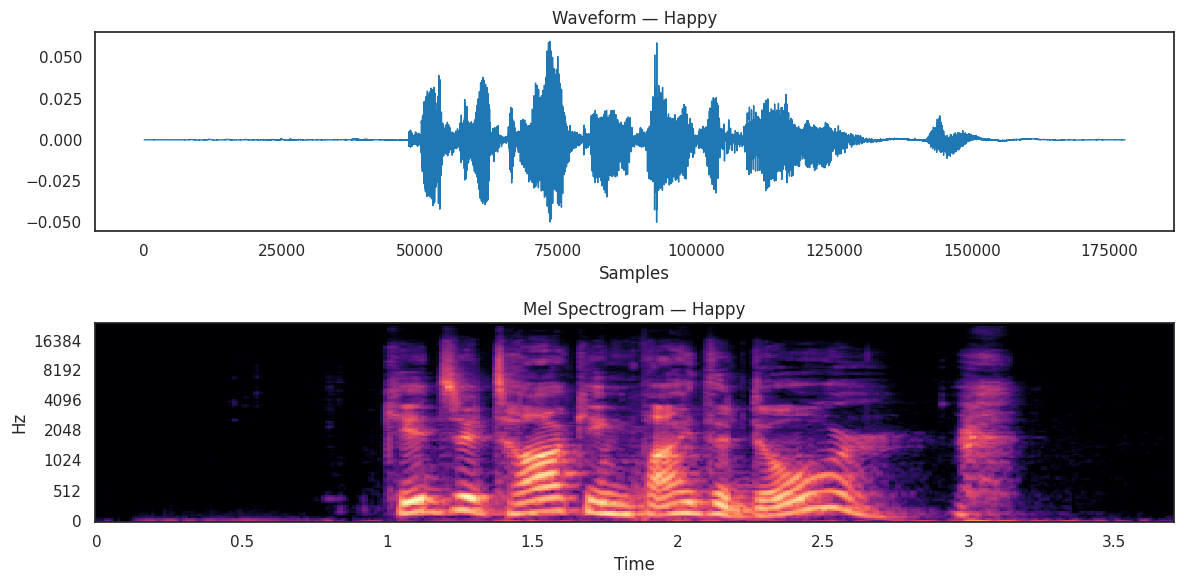

In [8]:
sample = df[df["emotion"] == "happy"]["path"].iloc[0]
y, sr = librosa.load(sample, sr=None)

print("Playing audio sample:")
ipd.display(ipd.Audio(y, rate=sr))

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

pd.Series(y).plot(ax=axes[0], lw=1, title="Waveform — Happy", color=color_pal[0])
axes[0].set_xlabel("Samples")

S = librosa.feature.melspectrogram(y=y, sr=sr)
S_db = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel Spectrogram — Happy")

plt.tight_layout()
plt.show()

In [9]:
def extract_mfcc(filepath, n_mfcc=40, max_len=174):
    y, sr = librosa.load(filepath, sr=None, duration=3)
    mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_len:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_len - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc

print("Extracting MFCCs... (takes ~1-2 min)")
X, y_labels = [], []

for _, row in df.iterrows():
    mfcc = extract_mfcc(row["path"])
    X.append(mfcc)
    y_labels.append(row["emotion"])

X        = np.array(X)
y_labels = np.array(y_labels)
print(f"✅ X shape: {X.shape}")  # (1440, 40, 174)

Extracting MFCCs... (takes ~1-2 min)
✅ X shape: (2880, 40, 174)


In [10]:
from sklearn.preprocessing   import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils  import to_categorical

le        = LabelEncoder()
y_enc     = le.fit_transform(y_labels)
y_cat     = to_categorical(y_enc)
n_classes = len(le.classes_)
print(f"Classes ({n_classes}): {le.classes_}")

X_cnn = X[..., np.newaxis]  # (1440, 40, 174, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_cat, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Classes (8): ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Train: (2304, 40, 174, 1) | Test: (576, 40, 174, 1)


In [11]:
from tensorflow.keras.models    import Sequential
from tensorflow.keras.layers    import (Conv2D, MaxPooling2D, Flatten,
                                         Dense, Dropout, BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(40, 174, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 174, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 174, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,440,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,536,520 (13.49 MB)

 Trainable params: 3,536,072 (13.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs          = 50,
    batch_size      = 32,
    validation_data = (X_test, y_test),
    callbacks       = [early_stop]
)

Epoch 1/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.1780 - loss: 3.3680 - val_accuracy: 0.1528 - val_loss: 2.0606
Epoch 2/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1914 - loss: 1.9979 - val_accuracy: 0.2101 - val_loss: 1.9858
Epoch 3/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1888 - loss: 1.9883 - val_accuracy: 0.2101 - val_loss: 1.9516
Epoch 4/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2001 - loss: 1.9831 - val_accuracy: 0.2691 - val_loss: 1.8891
Epoch 5/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2031 - loss: 1.9619 - val_accuracy: 0.2622 - val_loss: 1.8686
Epoch 6/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2001 - loss: 1.9566 - val_accuracy: 0.2552 - val_loss: 1.9179
Epoch 7/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2148 - loss: 1.9359 - val_accuracy: 0.2396 - val_loss: 1.8566
Epoch 8/50
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2270 - loss: 1.9124 - val_accuracy: 0.2743 - 

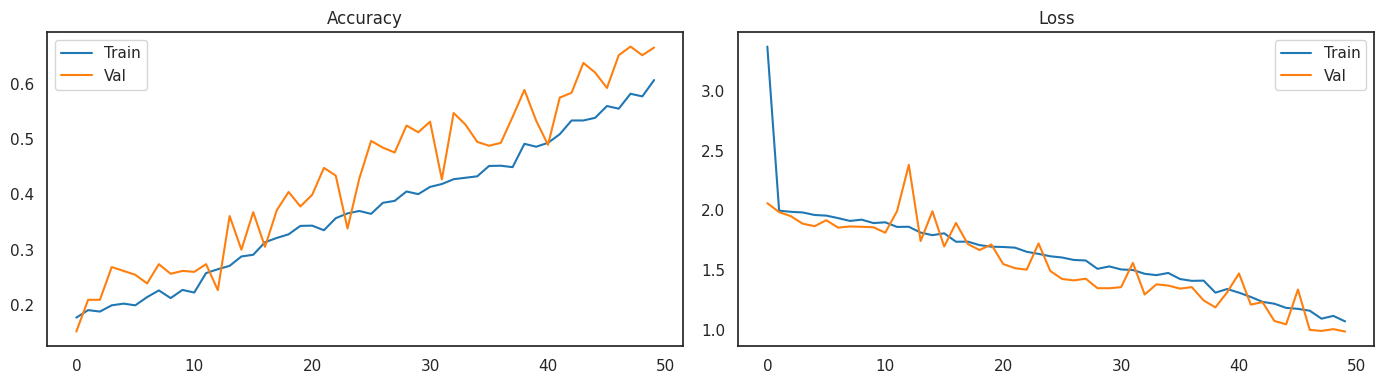


✅ Test Accuracy: 66.49%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


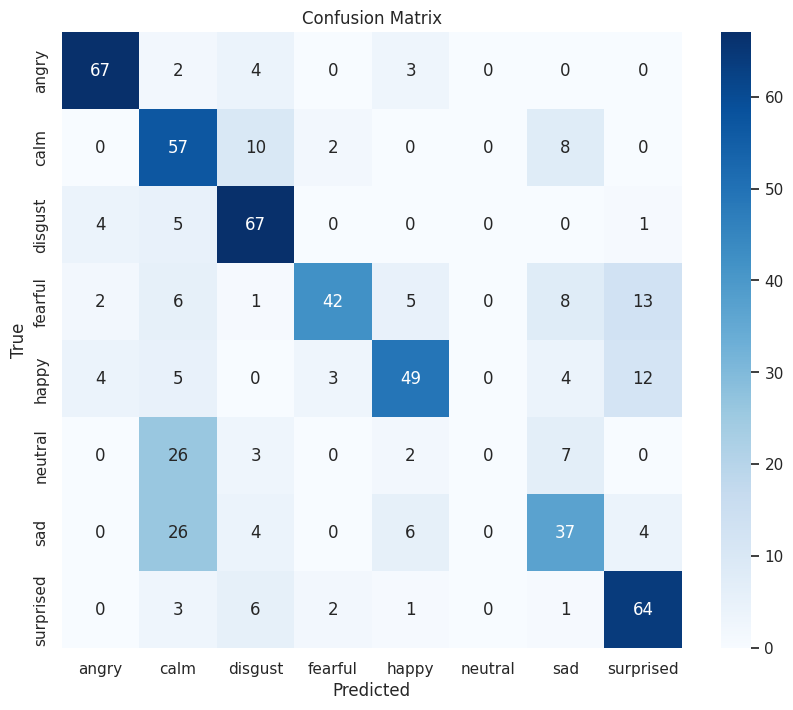

              precision    recall  f1-score   support

       angry       0.87      0.88      0.88        76
        calm       0.44      0.74      0.55        77
     disgust       0.71      0.87      0.78        77
     fearful       0.86      0.55      0.67        77
       happy       0.74      0.64      0.69        77
     neutral       0.00      0.00      0.00        38
         sad       0.57      0.48      0.52        77
   surprised       0.68      0.83      0.75        77

    accuracy                           0.66       576
   macro avg       0.61      0.62      0.60       576
weighted avg       0.65      0.66      0.64       576



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.show()

print(classification_report(y_true, y_pred, target_names=le.classes_))

In [19]:
def predict_emotion(filepath):
    mfcc = extract_mfcc(filepath)
    mfcc = mfcc[np.newaxis, ..., np.newaxis]

    prediction  = model.predict(mfcc, verbose=0)
    emotion_idx = np.argmax(prediction)
    emotion     = le.classes_[emotion_idx]
    confidence  = prediction[0][emotion_idx] * 100

    print(f"\n🎙️  File      : {os.path.basename(filepath)}")
    print(f"🎭  Emotion   : {emotion.upper()}")
    print(f"📊  Confidence: {confidence:.2f}%")
    print("\nAll probabilities:")
    for i, cls in enumerate(le.classes_):
        bar = "█" * int(prediction[0][i] * 30)
        print(f"  {cls:<12} {bar} {prediction[0][i]*100:.1f}%")

    ipd.display(ipd.Audio(filepath))  # play the audio too

# Upload any .wav and predict
uploaded = files.upload()
for filename in uploaded.keys():
    predict_emotion(filename)

Saving 03-01-03-02-02-01-01.wav to 03-01-03-02-02-01-01.wav

🎙️  File      : 03-01-03-02-02-01-01.wav
🎭  Emotion   : HAPPY
📊  Confidence: 61.79%

All probabilities:
  angry        ███ 12.5%
  calm          0.0%
  disgust       0.0%
  fearful      ███████ 23.8%
  happy        ██████████████████ 61.8%
  neutral       0.0%
  sad           0.1%
  surprised     1.7%
